# Hear Disease Prediction
We will train machine learning models for predicting Heart Failure of medical patients. Supervised classification learning task (binary target variable), DataSet for training is included in the directory: `data.csv`.


#### Features:

* Age: Age of the patient [years]
* Sex: Sex of the patient [M: male, F: female]
* Chest Pain Type: [TA: typical angina pectoris, ATA: atypical angina pectoris, NAP: non-anginal pain, ASY: no symptoms]
* Resting BP: Blood pressure of patient at rest [mm Hg]
* Cholesterol: serum cholesterol [mm/dl]
* Fasting BS: Blood sugar level [1: if BS > 120 mg/dl, 0: otherwise]
* Resting ECG: Results of Electrocardiogram of patient at rest
[Normal: normal, ST: ST-T wave abnormality, LVH: left heart chamber hypertrophy].
* Max HR: maximal reached heart rate [numeric value between 60 and 202]
* Exercise Angina: workout-induced angina pectoris [Y: Yes, N: No]
* Old peak: [Numeric Value measured at depression]
* ST_Slope: slope of ST segment during maximal load [Up: ascending, Flat: flat, Down: descending]
* Heart Disease: **Target variable we want to predict** [1: Heart Disease, 0: Normal]

We will try to train models with > **80 %** Testing Accuracy. We will train following models:
* Decision Tree
* Random Forest
* kNN
* AdaBoost (RF weak estimators)
* Logistic Regression

For each final model, we will also calculate ROC Curve, AUC Score and F1 Score.

We will split the DataSet into Training, Validation and Tesitng subsets in 70-15-15 ratios. We will do the model hyperparameter tuning with training the model on Training DataSet and measuring the Validation Accuracy on the Validation DataSet. Then after choosing the best hyperparameters for each model, we will train the final model on Training + Validation DataSet and measure the final Testing Accuracy on the Testing DataSet.

# Solution

## DataSet Preprocessing
We will start with loading the dataset and some inspection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
data_raw = pd.read_csv("data.csv")

In [3]:
data_raw

,ID,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,680,44,F,ASY,120,218,0,ST,115,N,0.0,Up,0
1,803,53,M,NAP,155,175,1,ST,160,N,0.3,Up,0
2,304,59,M,TA,170,288,0,LVH,159,N,0.2,Flat,1
3,137,50,M,ASY,140,341,0,ST,125,Y,2.5,Flat,1
4,840,34,M,TA,140,156,0,Normal,180,N,0.0,Flat,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,256,52,M,ASY,160,246,0,ST,82,Y,4.0,Flat,1
730,643,42,M,ATA,120,198,0,Normal,155,N,0.0,Up,0
731,249,48,M,ATA,140,238,0,Normal,118,N,0.0,Up,0
732,664,48,M,NAP,110,211,0,Normal,138,N,0.0,Up,0


We can use the original indexing and drop the `ID` column

In [4]:
data = data_raw.drop("ID", axis = 1)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             734 non-null    int64  
 1   Sex             734 non-null    str    
 2   ChestPainType   734 non-null    str    
 3   RestingBP       734 non-null    int64  
 4   Cholesterol     734 non-null    int64  
 5   FastingBS       734 non-null    int64  
 6   RestingECG      734 non-null    str    
 7   MaxHR           734 non-null    int64  
 8   ExerciseAngina  734 non-null    str    
 9   Oldpeak         734 non-null    float64
 10  ST_Slope        734 non-null    str    
 11  HeartDisease    734 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 68.9 KB


In [6]:
data.isna().any().sum()

np.int64(0)

Seems there are no `Nan` values in the DataSet, so we can move on to the proprcessing. We will start with training Decision Tree and Random Forest Models. Each model requires a little bit different preprocessing of the DataSet. In case of Decision Trees, there is no need for scaling the data, since it will not have any impact on the resulting model. We can however experiment with One-Hot encoding of categorical features with more than 2 unique values. For example it doesn't make sense to One-Hot encode the `Sex` feature. But first, we need to do the Train-Test split.

### Train-Valid-Test split
We will start with splitting the DataSet into the Training-Validation-Testing subsets in ratios 70/15/15.

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
ydata = data["HeartDisease"]
xdata = data.drop("HeartDisease", axis = 1)
rd_seed = 42
xtrain, xrest, ytrain, yrest = train_test_split(xdata, ydata, test_size = 0.3, random_state = rd_seed)
xvalid, xtest, yvalid, ytest = train_test_split(xrest, yrest, test_size = 0.5, random_state = rd_seed)

In [9]:
print("Check split sizes:")
print(f"Training DataSet: \nX Train: {xtrain.shape} \tY Train: {ytrain.shape}\n")
print(f"Validation DataSet: \nX Valid: {xvalid.shape} \tY Valid: {yvalid.shape}\n")
print(f"Testing DataSet: \nX Test: {xtest.shape} \tY Test: {ytest.shape}")

Check split sizes:
Training DataSet: 
X Train: (513, 11) 	Y Train: (513,)

Validation DataSet: 
X Valid: (110, 11) 	Y Valid: (110,)

Testing DataSet: 
X Test: (111, 11) 	Y Test: (111,)


### `Sex` Feature
Categorical feature with only 2 values, we can encode it using category codes.

In [10]:
sex_cat = pd.api.types.CategoricalDtype(categories = xtrain.Sex.dropna().unique(), ordered = False)
xtrain["Sex"] = xtrain["Sex"].astype(sex_cat).cat.codes
xvalid["Sex"] = xvalid["Sex"].astype(sex_cat).cat.codes
xtest["Sex"] = xtest["Sex"].astype(sex_cat).cat.codes

In [11]:
xtest.info()

<class 'pandas.DataFrame'>
Index: 111 entries, 714 to 51
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             111 non-null    int64  
 1   Sex             111 non-null    int8   
 2   ChestPainType   111 non-null    str    
 3   RestingBP       111 non-null    int64  
 4   Cholesterol     111 non-null    int64  
 5   FastingBS       111 non-null    int64  
 6   RestingECG      111 non-null    str    
 7   MaxHR           111 non-null    int64  
 8   ExerciseAngina  111 non-null    str    
 9   Oldpeak         111 non-null    float64
 10  ST_Slope        111 non-null    str    
dtypes: float64(1), int64(5), int8(1), str(4)
memory usage: 9.6 KB


### Categorical Features
Now we need to encode the other categorical features. Let's take a look at them:

In [12]:
category_features = ["ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
display(xtrain[category_features].head(15))
print("# of unique values in each categorical feature: \n", xtrain[category_features].nunique(), '\n', sep = '')
print("ChestPainType unique values:\n", xtrain["ChestPainType"].unique(), '\n')
print("RestingECG unique values:\n", xtrain["RestingECG"].unique(), '\n')
print("ExerciseAnging unique values:\n", xtrain["ExerciseAngina"].unique(), '\n')
print("ST_Slope unique values:\n", xtrain["ST_Slope"].unique())

,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
536,TA,ST,N,Flat
259,NAP,Normal,Y,Up
137,ASY,LVH,Y,Flat
227,NAP,ST,Y,Down
687,NAP,LVH,N,Flat
649,ASY,Normal,N,Flat
163,ATA,Normal,N,Up
583,ASY,LVH,Y,Flat
644,ATA,Normal,N,Up
494,ASY,Normal,N,Flat


# of unique values in each categorical feature: 
ChestPainType     4
RestingECG        3
ExerciseAngina    2
ST_Slope          3
dtype: int64

ChestPainType unique values:
 <StringArray>
['TA', 'NAP', 'ASY', 'ATA']
Length: 4, dtype: str 

RestingECG unique values:
 <StringArray>
['ST', 'Normal', 'LVH']
Length: 3, dtype: str 

ExerciseAnging unique values:
 <StringArray>
['N', 'Y']
Length: 2, dtype: str 

ST_Slope unique values:
 <StringArray>
['Flat', 'Up', 'Down']
Length: 3, dtype: str


feature `Exercise Angina` describes, wether patient feels chest pains during physical workout. I assume that healthy state is N (No Pain), but since this feature is only binary, we don't need to define any ordinality - Decision Tree models will handle binary-valued features just fine. In fact, we don't even need to One-Hot encode this feature and rather just encode it using category codes.

In [13]:
exer_ang_cat = pd.api.types.CategoricalDtype(categories = xtrain["ExerciseAngina"].dropna().unique(), ordered = False)
for each in [xtrain, xvalid, xtest]:
    each["ExerciseAngina"] = each["ExerciseAngina"].astype(exer_ang_cat).cat.codes

Feature `ST_Slope` describes shape of the EKG curve. Healthy state is "Flat", and both "Up" and "Down" shapes may indicate some kind of heart prblems. Without any deeper medical knowledge, we can't meaningfully define the ordinality of this feature in terms of medical urgency (severity of listed conditions), so we will just encode this feature either with unordered category codes, or using One-Hot encoding. This proces will not raise the dimensionality of the DataSet significantly, since there are only 3 unique values of the `ST_Slope feature`.

We can use the same arguments for features `ChesPainType` and `RestingEKG`, so we will apply the same processing procedure described above.

We will now define a function that processes those mentioned features using either One-Hot encoding or unordered category codes.

In [14]:
def process_category_features(xtrain, xvalid, xtest, one_hot = False):
    xtrain_data = xtrain.copy()
    xvalid_data = xvalid.copy()
    xtest_data = xtest.copy()
    category_features = ["ChestPainType", "RestingECG", "ST_Slope"]
    for feature in category_features:
        temp_cat = pd.api.types.CategoricalDtype(categories = xtrain_data[feature].dropna().unique(), ordered = False)
        for data in [xtrain_data, xvalid_data, xtest_data]:
            data[feature] = data[feature].astype(temp_cat)
            if not one_hot:
                data[feature] = data[feature].cat.codes
        if one_hot:
            xtrain_data = pd.get_dummies(xtrain_data, columns = [feature])
            xvalid_data = pd.get_dummies(xvalid_data, columns = [feature])
            xtest_data = pd.get_dummies(xtest_data, columns = [feature])
    return xtrain_data, xvalid_data, xtest_data

All other features are quantitative and have numeric value in the original DataSet, so we don't need to preprocess them anymore.

## Model Training

In [15]:
from sklearn.model_selection import ParameterGrid
import sklearn.metrics as mtr
from sklearn.tree import DecisionTreeClassifier

### Decision Tree Model
We can start with training the Decision Tree Model. First step is to tune the hyperparameters. Those are:
* `max_depth` - max depth of the Decision Tree
* `criterion = entropy/gini` - metric we use to maximize the information gain in the process of creating the Tree branches (splits).
* `One-Hot encoding = True/False`

In [16]:
DT_max_depth = 20
DT_param_grid = {"max_depth" : range(1, DT_max_depth + 1),
                 "criterion" : ["entropy", "gini"],
                "arg_one_hot" : [True, False]}
DT_params = ParameterGrid(DT_param_grid)

DT_accu_train_all = []
DT_accu_valid_all = []

for each in DT_params:
    arg_one_hot = each.pop("arg_one_hot")
    xtrain_DT, xvalid_DT, xtest_DT = process_category_features(xtrain, xvalid, xtest, one_hot = arg_one_hot)
    DT = DecisionTreeClassifier(**each, random_state = rd_seed).fit(xtrain_DT, ytrain)
    accu_train_this = mtr.accuracy_score(ytrain, DT.predict(xtrain_DT))
    accu_valid_this = mtr.accuracy_score(yvalid, DT.predict(xvalid_DT))
    DT_accu_train_all.append(accu_train_this)
    DT_accu_valid_all.append(accu_valid_this)
    print(f"Decision Tree Classification Model parameters: One-Hot encoding {arg_one_hot}, {each} \tTraining Accuracy = {accu_train_this:.6f}\tValidation Accuracy = {accu_valid_this:.6f}")

Decision Tree Classification Model parameters: One-Hot encoding True, {'criterion': 'entropy', 'max_depth': 1} 	Training Accuracy = 0.816764	Validation Accuracy = 0.809091
Decision Tree Classification Model parameters: One-Hot encoding True, {'criterion': 'entropy', 'max_depth': 2} 	Training Accuracy = 0.818713	Validation Accuracy = 0.772727
Decision Tree Classification Model parameters: One-Hot encoding True, {'criterion': 'entropy', 'max_depth': 3} 	Training Accuracy = 0.861598	Validation Accuracy = 0.827273
Decision Tree Classification Model parameters: One-Hot encoding True, {'criterion': 'entropy', 'max_depth': 4} 	Training Accuracy = 0.892788	Validation Accuracy = 0.790909
Decision Tree Classification Model parameters: One-Hot encoding True, {'criterion': 'entropy', 'max_depth': 5} 	Training Accuracy = 0.912281	Validation Accuracy = 0.809091
Decision Tree Classification Model parameters: One-Hot encoding True, {'criterion': 'entropy', 'max_depth': 6} 	Training Accuracy = 0.935673

In [17]:
DT_best_index = np.argmax(DT_accu_valid_all)
DT_accu_valid_best = DT_accu_valid_all[DT_best_index]
DT_params_best = DT_params[DT_best_index]
print(f"We found the best Decision Tree Classifier Model with parameters {DT_params_best} and Validation Accuaracy = {DT_accu_valid_best:.4f}")

We found the best Decision Tree Classifier Model with parameters {'max_depth': 5, 'criterion': 'gini', 'arg_one_hot': True} and Validation Accuaracy = 0.8455


We can visualise the results:

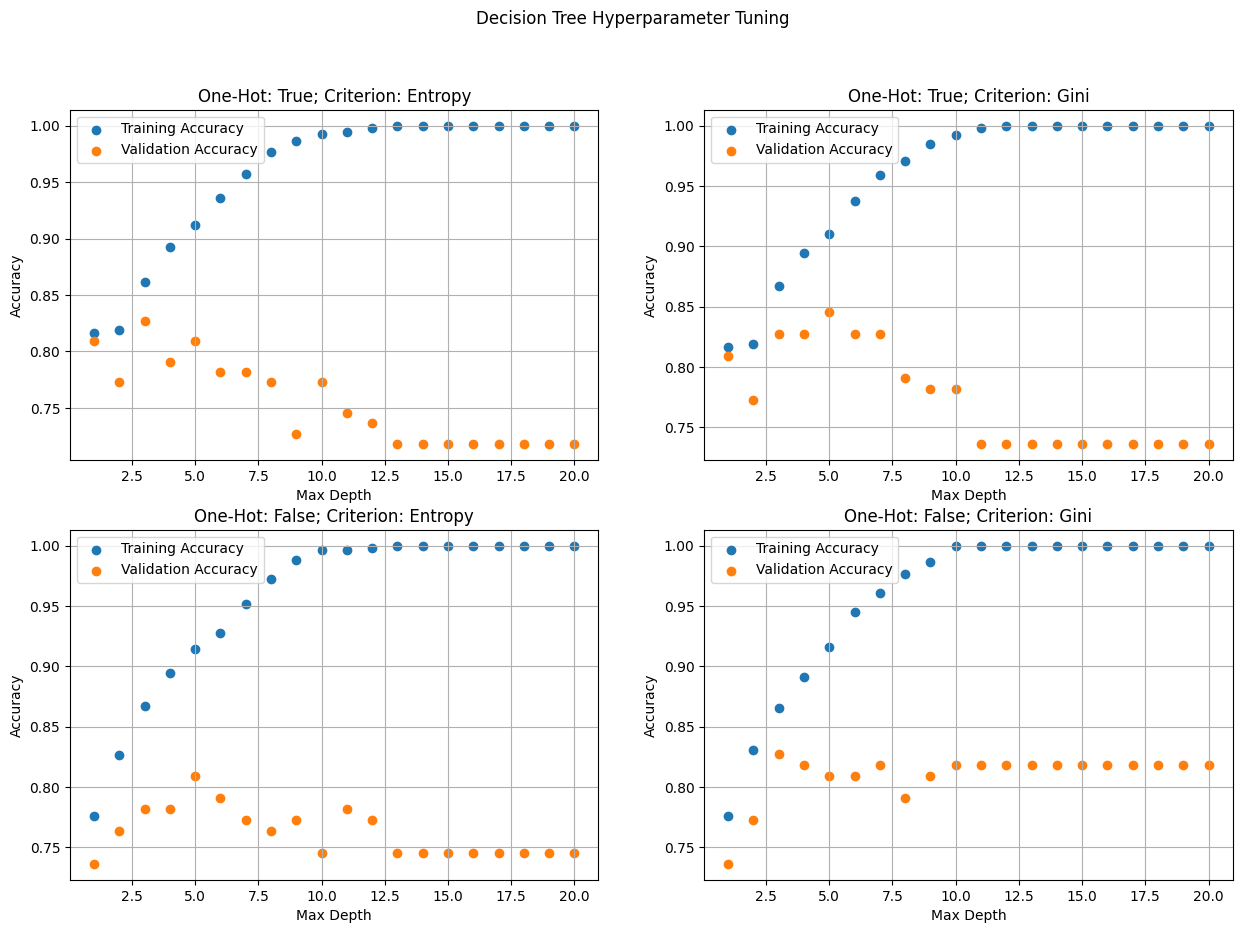

In [18]:
plt.figure(figsize = (15, 10))
plt.suptitle("Decision Tree Hyperparameter Tuning")
plt.subplot(221)
plt.scatter(range(1, DT_max_depth + 1), DT_accu_train_all[0 : DT_max_depth], label = "Training Accuracy")
plt.scatter(range(1, DT_max_depth + 1), DT_accu_valid_all[0 : DT_max_depth], label = "Validation Accuracy")
plt.legend()
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.grid()
plt.title("One-Hot: True; Criterion: Entropy")

plt.subplot(222)
plt.scatter(range(1, DT_max_depth + 1), DT_accu_train_all[DT_max_depth : DT_max_depth * 2], label = "Training Accuracy")
plt.scatter(range(1, DT_max_depth + 1), DT_accu_valid_all[DT_max_depth : DT_max_depth * 2], label = "Validation Accuracy")
plt.legend()
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.grid()
plt.title("One-Hot: True; Criterion: Gini")

plt.subplot(223)
plt.scatter(range(1, DT_max_depth + 1), DT_accu_train_all[DT_max_depth * 2 : DT_max_depth * 3], label = "Training Accuracy")
plt.scatter(range(1, DT_max_depth + 1), DT_accu_valid_all[DT_max_depth * 2 : DT_max_depth * 3], label = "Validation Accuracy")
plt.legend()
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.grid()
plt.title("One-Hot: False; Criterion: Entropy")

plt.subplot(224)
plt.scatter(range(1, DT_max_depth + 1), DT_accu_train_all[DT_max_depth * 3 : DT_max_depth * 4], label = "Training Accuracy")
plt.scatter(range(1, DT_max_depth + 1), DT_accu_valid_all[DT_max_depth * 3 : DT_max_depth * 4], label = "Validation Accuracy")
plt.legend()
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.grid()
plt.title("One-Hot: False; Criterion: Gini")

plt.show()

### Decision Tree Final Model
We will now train the final prediction model of the Decision Tree with chosen best parameters. We will train it on Training + Validation DataSets and measure the final Testing Accuracy on the Testing DataSet.

In [19]:
DT_final_one_hot = DT_params_best.pop("arg_one_hot")
xtrain_DT_final, xvalid_DT_final, xtest_DT_final = process_category_features(xtrain, xvalid, xtest, one_hot = DT_final_one_hot)
xtrain_DT_final = pd.concat([xtrain_DT_final, xvalid_DT_final], axis = 0)
ytrain_DT_final = pd.concat([ytrain, yvalid], axis = 0)
DT_final = DecisionTreeClassifier(**DT_params_best, random_state = rd_seed).fit(xtrain_DT_final, ytrain_DT_final)
DT_final_accu_train = mtr.accuracy_score(ytrain_DT_final, DT_final.predict(xtrain_DT_final))
DT_final_accu_test = mtr.accuracy_score(ytest, DT_final.predict(xtest_DT_final))
print(f"We have trained the final Decision Tree Classifier Model with Training Accuracy = {DT_final_accu_train:.5f} and Testing Accuracy = {DT_final_accu_test:.5f}")

We have trained the final Decision Tree Classifier Model with Training Accuracy = 0.90851 and Testing Accuracy = 0.82883


Our task was to train a model with Accuracy > **80 %**. We have reached Testing Accuracy 82,9 %, so we can consider this model successful.

DT parameters:
* `One-Hot = True, Criterion = Gini, Max Tree Depth = 5`

Let's visualise our final DT model:

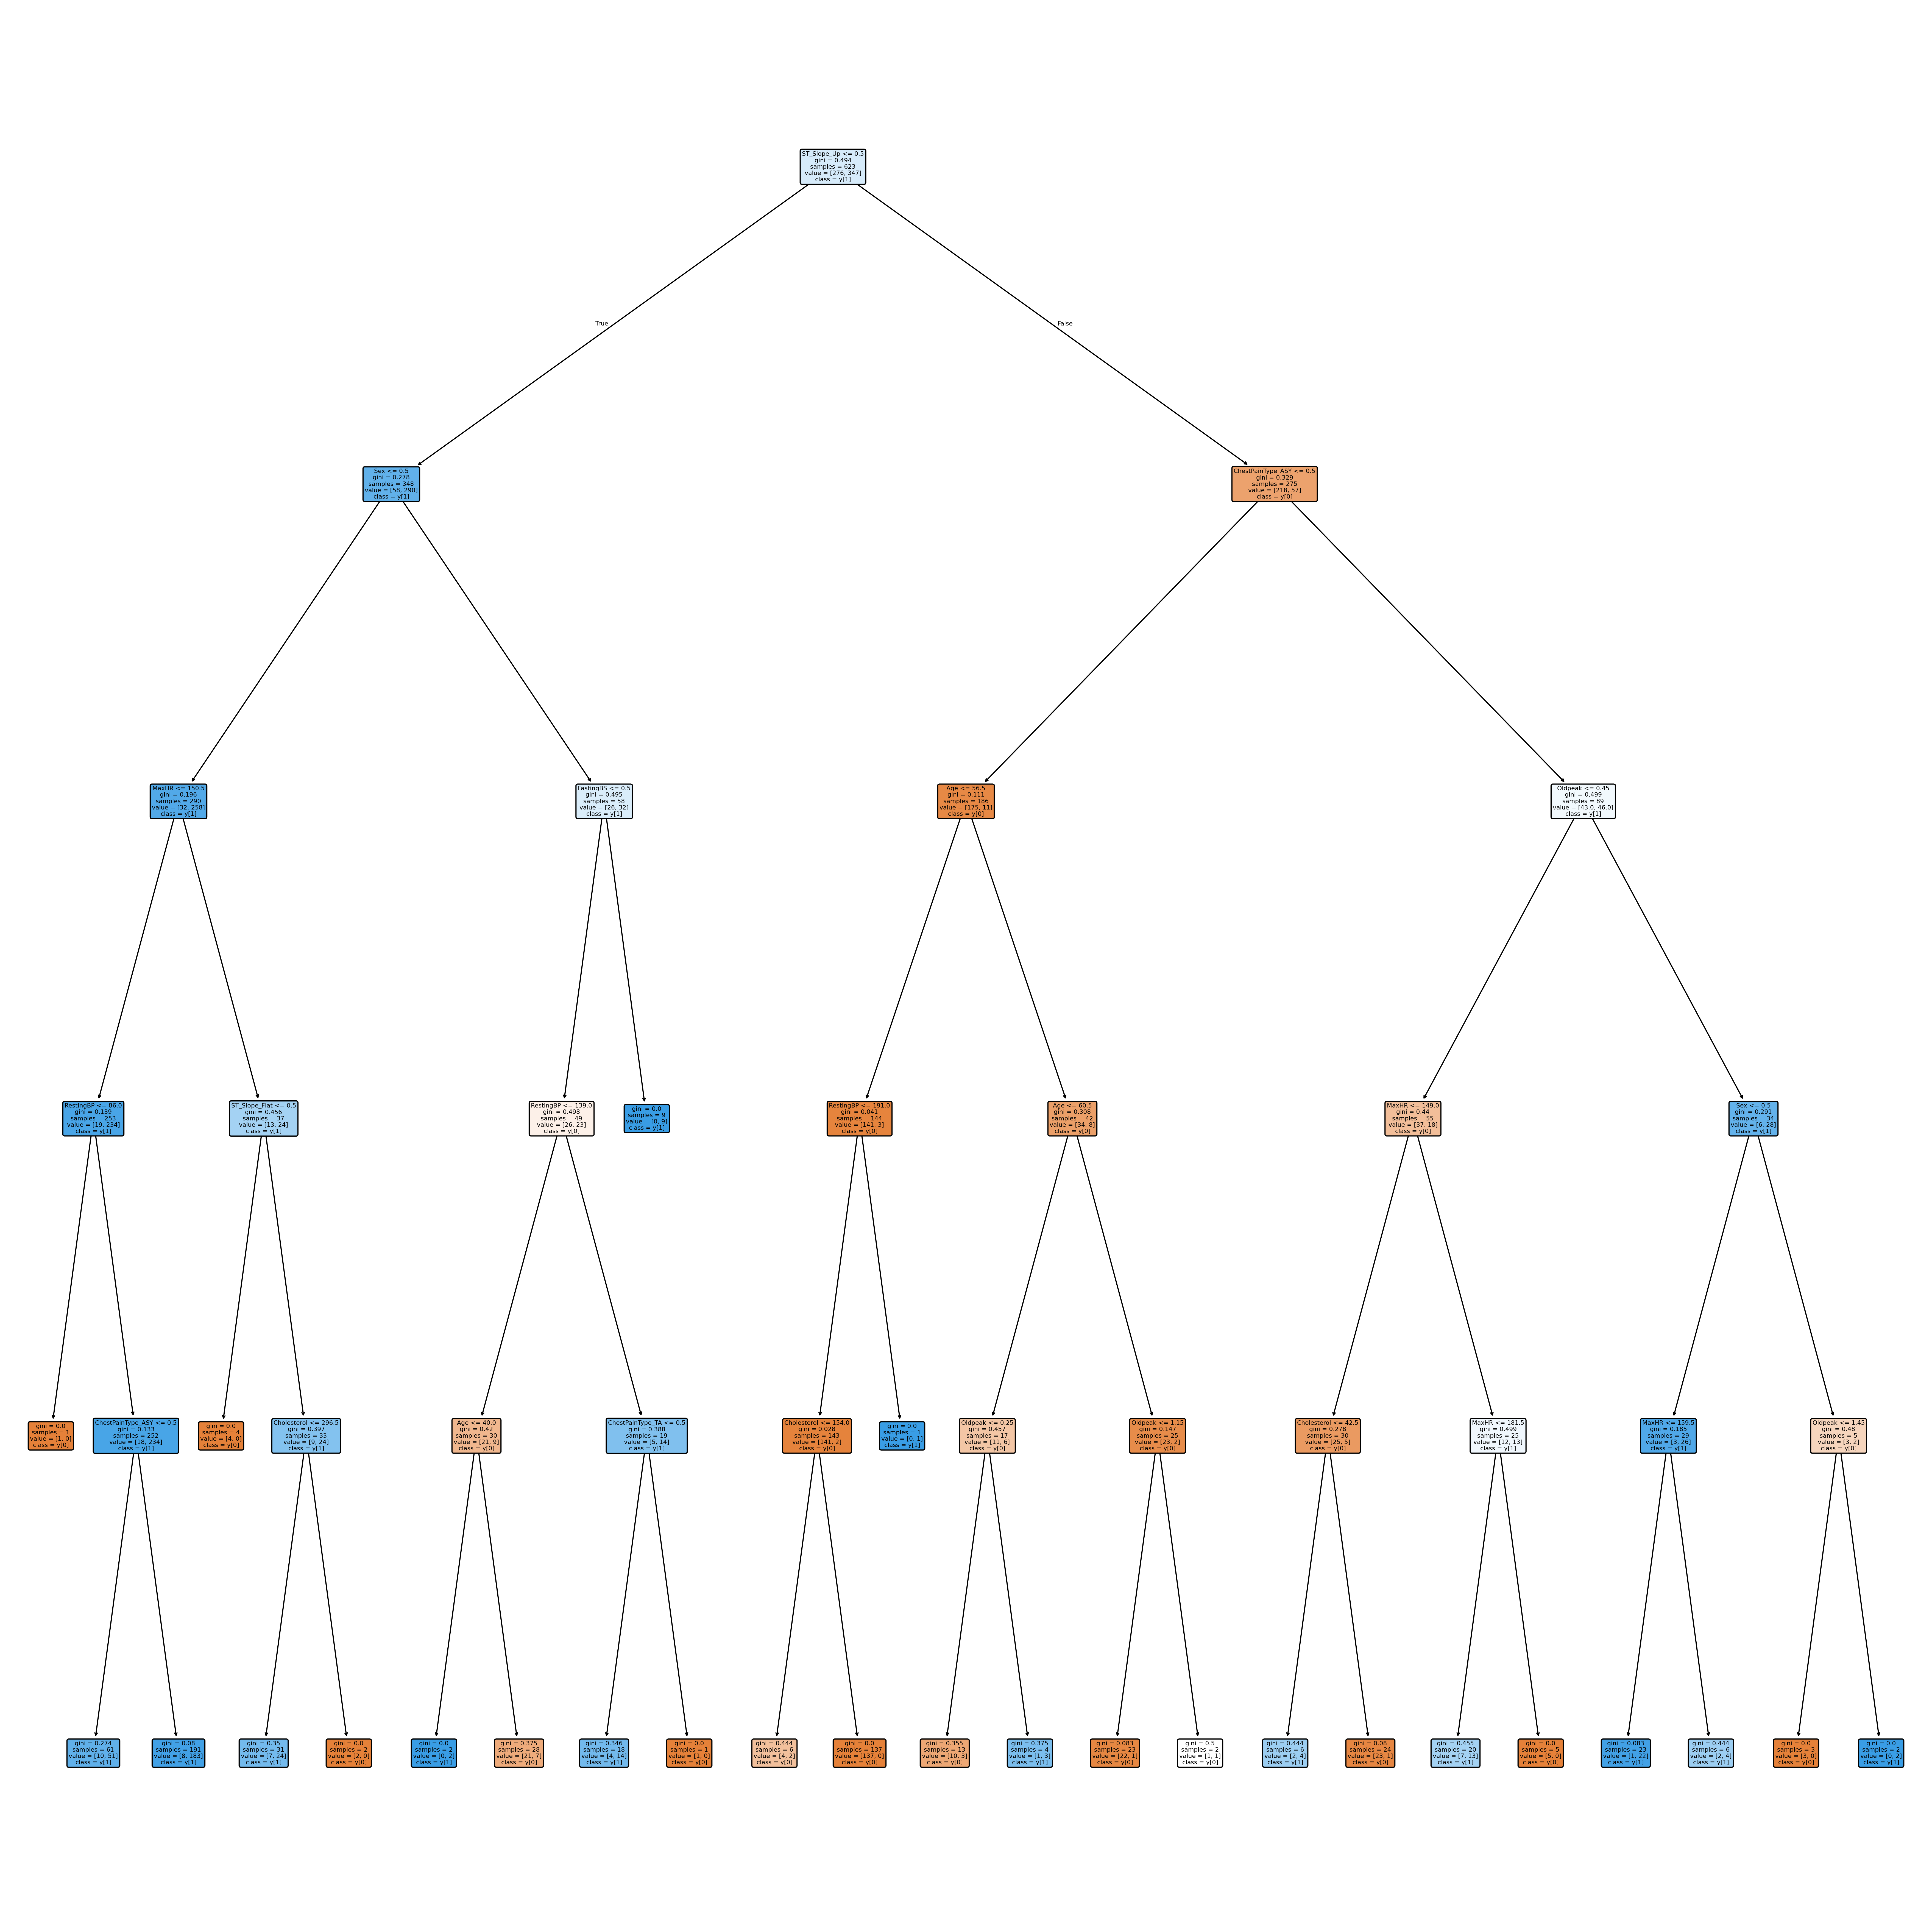

In [20]:
from sklearn.tree import plot_tree

plt.figure(figsize=(30, 30), dpi = 300)
plot_tree(DT_final, filled=True, feature_names = xtrain_DT_final.columns, class_names=True, rounded=True)
plt.savefig('DT_final', dpi = 250)

Part of the task was to plot the ROC Curve and calculate the AUC Score and F1 Score, so let's do it:

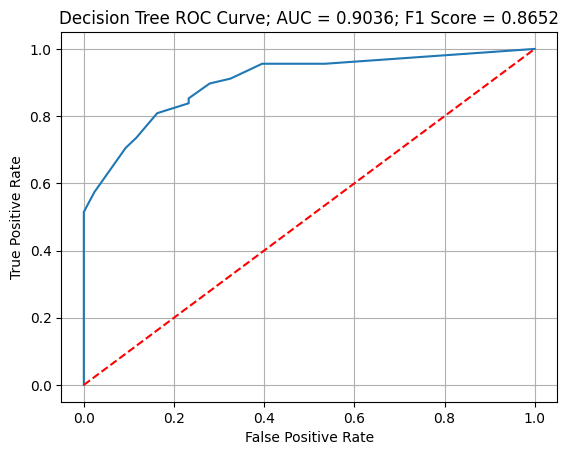

In [21]:
fpr, tpr, thresholds = mtr.roc_curve(ytest, DT_final.predict_proba(xtest_DT_final)[:, 1])
AUC = mtr.auc(fpr, tpr)
f1_DT_final = mtr.f1_score(ytest, DT_final.predict(xtest_DT_final))

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Decision Tree ROC Curve; AUC = {AUC:.4f}; F1 Score = {f1_DT_final:.4f}")
plt.grid()

### Random Forest Model
We will now train the Random Forest Prediction Model.

In [22]:
# Load dataset, drop "ID" column, split DataSet into Feature matrix and Target Variable vector
data_raw = pd.read_csv("data.csv")
data = data_raw.drop("ID", axis = 1)
ydata = data["HeartDisease"]
xdata = data.drop("HeartDisease", axis = 1)

# Train-Valid-Test split - ratios 70/15/15
xtrain, xrest, ytrain, yrest = train_test_split(xdata, ydata, test_size = 0.3, random_state = rd_seed)
xvalid, xtest, yvalid, ytest = train_test_split(xrest, yrest, test_size = 0.5, random_state = rd_seed)

# Encode "Sex" feature using category codes (binary-valued feature)
sex_cat = pd.api.types.CategoricalDtype(categories = xtrain.Sex.dropna().unique(), ordered = False)
xtrain["Sex"] = xtrain["Sex"].astype(sex_cat).cat.codes
xvalid["Sex"] = xvalid["Sex"].astype(sex_cat).cat.codes
xtest["Sex"] = xtest["Sex"].astype(sex_cat).cat.codes

# Encode "Exercise Angina" feature using category codes (binary-valued feature)
exer_ang_cat = pd.api.types.CategoricalDtype(categories = xtrain["ExerciseAngina"].dropna().unique(), ordered = False)
for each in [xtrain, xvalid, xtest]:
    each["ExerciseAngina"] = each["ExerciseAngina"].astype(exer_ang_cat).cat.codes

We can reuse the function `process_category_features` that we have used in the training of Decision Tree Model. Now we can move on to the hyperparameter tuning of our Random Forest Prediction Model. First we need to define the hyperparameter grid. Hyperparameters to tune:
* `n_estimators = 2 - 50` - # of Trees in the Random Forest
* `max_depth = 1 - 10` - Maximal depth of each Tree
* `criterion = entropy/gini`
* `One-Hot = True/False`

We will not tune other parameters as for example `max_features` (# of features to consider during the splittings of each tree, default is sqrt of all features). Since our parameter grid will have 4 dimensions, we will not visualise the results, as that would require too many plots. We will only select the best performing model based on the Validation Accuracy, so we will not calculate and save the Training Accuracy.

In [23]:
from sklearn.ensemble import RandomForestClassifier

In [24]:
RF_max_depth = 10
RF_parameter_grid = {"n_estimators" : range(2, 51),
                   "max_depth" : range(1, RF_max_depth + 1),
                   "criterion" : ["entropy", "gini"],
                   "arg_one_hot" : [True, False]}

RF_params = ParameterGrid(RF_parameter_grid)
RF_accu_valid_all = []

for each in RF_params:
    arg_one_hot = each.pop("arg_one_hot")
    xtrain_RF, xvalid_RF, xtest_RF = process_category_features(xtrain, xvalid, xtest, one_hot = arg_one_hot)
    RF = RandomForestClassifier(**each, random_state = rd_seed).fit(xtrain_RF, ytrain)
    RF_accu_valid_this = mtr.accuracy_score(yvalid, RF.predict(xvalid_RF))
    RF_accu_valid_all.append(RF_accu_valid_this)
    print(f"Random Forest Model parameters: {each} \t Validation Accuracy: {RF_accu_valid_this:.5f}")

Random Forest Model parameters: {'criterion': 'entropy', 'max_depth': 1, 'n_estimators': 2} 	 Validation Accuracy: 0.65455
Random Forest Model parameters: {'criterion': 'entropy', 'max_depth': 1, 'n_estimators': 3} 	 Validation Accuracy: 0.65455
Random Forest Model parameters: {'criterion': 'entropy', 'max_depth': 1, 'n_estimators': 4} 	 Validation Accuracy: 0.65455
Random Forest Model parameters: {'criterion': 'entropy', 'max_depth': 1, 'n_estimators': 5} 	 Validation Accuracy: 0.68182
Random Forest Model parameters: {'criterion': 'entropy', 'max_depth': 1, 'n_estimators': 6} 	 Validation Accuracy: 0.69091
Random Forest Model parameters: {'criterion': 'entropy', 'max_depth': 1, 'n_estimators': 7} 	 Validation Accuracy: 0.80909
Random Forest Model parameters: {'criterion': 'entropy', 'max_depth': 1, 'n_estimators': 8} 	 Validation Accuracy: 0.80909
Random Forest Model parameters: {'criterion': 'entropy', 'max_depth': 1, 'n_estimators': 9} 	 Validation Accuracy: 0.80909
Random Forest Mo

In [25]:
RF_best_index = np.argmax(RF_accu_valid_all)
RF_accu_valid_best = RF_accu_valid_all[RF_best_index]
RF_params_best = RF_params[RF_best_index]

print(f"We have found the best Random Forest Parameters {RF_params_best} with Validation Accuracy {RF_accu_valid_best:.5f}")

We have found the best Random Forest Parameters {'n_estimators': 46, 'max_depth': 7, 'criterion': 'entropy', 'arg_one_hot': True} with Validation Accuracy 0.90000


We have found the best hyperparameter values:
* `n_estimators = 46`
* `max_depth = 7`
* `criterion = entropy`
* `One-hot = True`

### Random Forest Final Model
After hyperparameter tuning we can move on to training the final Random Forest Model:

In [26]:
arg_one_hot = RF_params_best.pop("arg_one_hot")
xtrain_RF_final, xvalid_RF_final, xtest_RF_final = process_category_features(xtrain, xvalid, xtest, one_hot = arg_one_hot)
xtrain_RF_final = pd.concat([xtrain_RF_final, xvalid_RF_final], axis = 0)
ytrain_final = pd.concat([ytrain, yvalid], axis = 0)
RF_final = RandomForestClassifier(**RF_params_best, random_state = rd_seed).fit(xtrain_RF_final, ytrain_final)
RF_accu_test = mtr.accuracy_score(ytest, RF_final.predict(xtest_RF_final))
print(f"Final Random Forest Model Testing Accuracy = {RF_accu_test:.5f}")

Final Random Forest Model Testing Accuracy = 0.86486


Testing Accuracy of our Final Random Forest Model is 86,5 %, which is higher than requested accuracy of **80 %**. We can consider our Random Forest Prediction Model successful.

Finally we can plot the ROC Curve and calculate the AUC score:

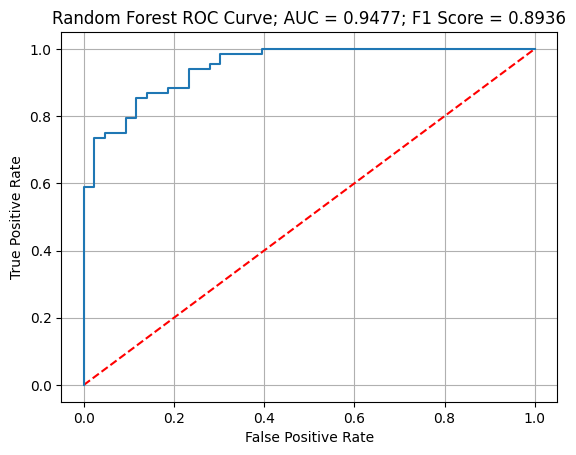

In [27]:
fpr, tpr, thresholds = mtr.roc_curve(ytest, RF_final.predict_proba(xtest_RF_final)[:, 1])
AUC = mtr.auc(fpr, tpr)
f1_RF_final = mtr.f1_score(ytest, RF_final.predict(xtest_RF_final))

plt.plot([0, 1], [0, 1], 'r--')
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Random Forest ROC Curve; AUC = {AUC:.4f}; F1 Score = {f1_RF_final:.4f}")
plt.grid()

### kNN
Now we will train K Nearest Neighbors Classification Model. We can copy the preprocessing code from previous models. We will use One-Hot encoding defaultly and tune other hyperparameters of the model, so we can use our process_category_features function with parameter `one-hot = True`.

In [28]:
# Load dataset, drop "ID" column, split DataSet into Feature matrix and Target Variable vector
data_raw = pd.read_csv("data.csv")
data = data_raw.drop("ID", axis = 1)
ydata = data["HeartDisease"]
xdata = data.drop("HeartDisease", axis = 1)

# Train-Valid-Test split - ratios 70/15/15
xtrain, xrest, ytrain, yrest = train_test_split(xdata, ydata, test_size = 0.3, random_state = rd_seed)
xvalid, xtest, yvalid, ytest = train_test_split(xrest, yrest, test_size = 0.5, random_state = rd_seed)

# Encode "Sex" feature using category codes (binary-valued feature)
sex_cat = pd.api.types.CategoricalDtype(categories = xtrain.Sex.dropna().unique(), ordered = False)
for each in [xtrain, xvalid, xtest]:
    each["Sex"] = each["Sex"].astype(sex_cat).cat.codes
    
# Encode "Exercise Angina" feature using category codes (binary-valued feature)
exer_ang_cat = pd.api.types.CategoricalDtype(categories = xtrain["ExerciseAngina"].dropna().unique(), ordered = False)
for each in [xtrain, xvalid, xtest]:
    each["ExerciseAngina"] = each["ExerciseAngina"].astype(exer_ang_cat).cat.codes

In [29]:
xtrain_knn, xvalid_knn, xtest_knn = process_category_features(xtrain, xvalid, xtest, one_hot = True)

Now we need to Normalise the data, since this is an important step in training kNN Models:
* `Age` - Min-Max scaler

In [30]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

In [31]:
print(f"Min Age in Trining DataSet: {xtrain_knn["Age"].min()}")
print(f"Max Age in Training DataSet: {xtrain_knn["Age"].max()}")
xtrain_knn["Age"]

Min Age in Trining DataSet: 29
Max Age in Training DataSet: 77


536    49
259    44
137    45
227    48
687    72
       ..
71     56
106    64
270    64
435    66
102    72
Name: Age, Length: 513, dtype: int64

Those Data look fine, we can use the Min-Max Scaler right away.

In [32]:
age_scaler = MinMaxScaler().fit(xtrain_knn[["Age"]])
for each in [xtrain_knn, xvalid_knn, xtest_knn]:
    each["Age"] = age_scaler.transform(each[["Age"]])

* `RestingBP` - Standard scaler - this is a feature representing a numeric medical condition among population, we can expect it follows Normal Distribution, so I will use Standard scaler to transform it into N(0,1)

In [33]:
print(f"RestingBP min value in Training DataSet: {xtrain_knn["RestingBP"].min()}")
print(f"RestingBP max value in Training DataSet: {xtrain_knn["RestingBP"].max()}")
xtrain_knn["RestingBP"]

RestingBP min value in Training DataSet: 92
RestingBP max value in Training DataSet: 200


536    130
259    130
137    104
227    102
687    160
      ... 
71     130
106    142
270    130
435    110
102    143
Name: RestingBP, Length: 513, dtype: int64

Those Data look fine, we can use Standard Scaler.

In [34]:
bp_scaler = StandardScaler().fit(xtrain_knn[["RestingBP"]])
for each in [xtrain_knn, xvalid_knn, xtest_knn]:
    each["RestingBP"] = bp_scaler.transform(each[["RestingBP"]])

* `Cholesterol` feature - we will use Standard Scaler again

In [35]:
print(f"Min value of Cholesterol among Training DataSet: {xtrain_knn["Cholesterol"].min()}")
print(f"Max value of Cholesterol among Training DataSet: {xtrain_knn["Cholesterol"].max()}")
display(xtrain_knn[["Cholesterol"]])
xtrain_knn[["Cholesterol"]].describe()

Min value of Cholesterol among Training DataSet: 0
Max value of Cholesterol among Training DataSet: 564


,Cholesterol
536,0
259,233
137,208
227,0
687,0
...,...
71,221
106,276
270,223
435,213


,Cholesterol
count,513.000000
mean,194.220273
std,109.309070
min,0.000000
25%,168.000000
50%,220.000000
75%,266.000000
max,564.000000


Those 0 values here are actually missing values. Before scaling, we will replace them with `NaN` and then after scaling replace those `NaNs` back with 0s or -1s.

In [36]:
for each in [xtrain_knn, xvalid_knn, xtest_knn]:
    each["Cholesterol"] = each["Cholesterol"].replace(0, np.nan)

In [37]:
cholesterol_scaler = StandardScaler().fit(xtrain_knn[["Cholesterol"]])
for each in [xtrain_knn, xvalid_knn, xtest_knn]:
    each["Cholesterol"] = cholesterol_scaler.transform(each[["Cholesterol"]])

In [38]:
for each in [xtrain_knn, xvalid_knn, xtest_knn]:
    each["Cholesterol"] = each["Cholesterol"].fillna(0)

In [39]:
xvalid_knn

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_TA,ChestPainType_NAP,ChestPainType_ASY,ChestPainType_ATA,RestingECG_ST,RestingECG_Normal,RestingECG_LVH,ST_Slope_Flat,ST_Slope_Up,ST_Slope_Down
39,0.666667,0,0.106389,-0.148865,0,145,0,2.6,True,False,False,False,False,True,False,True,False,False
375,0.604167,0,-1.544033,-0.042797,0,154,1,0.6,False,True,False,False,False,False,True,True,False,False
90,0.833333,1,0.447856,-0.060475,0,151,0,1.8,True,False,False,False,False,True,False,False,True,False
462,0.833333,0,0.277123,0.000000,0,104,1,1.6,False,False,True,False,True,False,False,True,False,False
235,0.812500,0,0.732412,0.000000,1,136,0,1.8,False,False,True,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334,0.354167,0,-0.804189,-0.997411,0,124,0,0.0,False,False,True,False,False,True,False,True,False,False
66,0.541667,0,0.447856,-0.237256,0,110,1,0.5,False,False,True,False,False,True,False,True,False,False
698,0.854167,0,0.732412,-1.209547,0,125,1,2.6,False,False,True,False,False,True,False,False,False,True
319,0.541667,0,2.269012,0.310763,0,73,0,2.0,False,False,True,False,False,True,False,True,False,False


The optimal representation of missing values for the kNN model is unclear. Representing them as 0s tells the model, that their values are actually mean among the DataSet, while -1 tells they are 1 standard deviation from mean. Maybe a good way would be to create a new boolean feature indicating only missing values in this `Cholesterol` feature, but that would raise dimension of the DataSet, which we want to avoid. We will keep them as 0s for now. This makes sense in a way, since as we don't know the value of `Cholesterol` feature with `NaN` values, we can represent them with mean value of this feature.

* `MaxHR` feature - Standard Scaler

In [40]:
print(f"Min value of MaxHR among Training DataSet: {xtrain_knn["MaxHR"].min()}")
print(f"Max value of MaxHR among Training DataSet: {xtrain_knn["MaxHR"].max()}")
xtrain_knn["MaxHR"].describe()

Min value of MaxHR among Training DataSet: 63
Max value of MaxHR among Training DataSet: 195


count    513.000000
mean     136.918129
std       25.190313
min       63.000000
25%      120.000000
50%      137.000000
75%      156.000000
max      195.000000
Name: MaxHR, dtype: float64

Those data look good, we can use Standard Scaler:

In [41]:
HR_scaler = StandardScaler().fit(xtrain_knn[["MaxHR"]])
for each in [xtrain_knn, xvalid_knn, xtest_knn]:
    each["MaxHR"] = HR_scaler.transform(each[["MaxHR"]])

In [42]:
xtest_knn["MaxHR"].describe()

count    111.000000
mean       0.037978
std        1.050676
min       -3.056461
25%       -0.672268
50%        0.201936
75%        0.797984
max        2.586129
Name: MaxHR, dtype: float64

* `Oldpeak` feature

In [43]:
xtrain_knn["Oldpeak"].describe()

count    513.000000
mean       0.901559
std        1.068146
min       -1.500000
25%        0.000000
50%        0.600000
75%        1.500000
max        5.000000
Name: Oldpeak, dtype: float64

Seems fine

In [44]:
oldpeak_scaler = StandardScaler().fit(xtrain_knn[["Oldpeak"]])
for each in [xtrain_knn, xvalid_knn, xtest_knn]:
    each["Oldpeak"] = oldpeak_scaler.transform(each[["Oldpeak"]])

In [45]:
xtrain_knn.describe()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak
count,513.000000,513.000000,5.130000e+02,5.130000e+02,513.000000,5.130000e+02,513.000000,5.130000e+02
mean,0.512183,0.222222,-1.939103e-16,1.038805e-16,0.253411,9.002978e-17,0.409357,3.808952e-17
std,0.196521,0.416146,1.000976e+00,8.959544e-01,0.435389,1.000976e+00,0.492195,1.000976e+00
min,0.000000,0.000000,-2.283878e+00,-2.782892e+00,0.000000,-2.937251e+00,0.000000,-2.250539e+00
25%,0.395833,0.000000,-6.903664e-01,-5.201040e-01,0.000000,-6.722680e-01,0.000000,-8.448656e-01
50%,0.520833,0.000000,-1.212551e-01,0.000000e+00,0.000000,3.253285e-03,0.000000,-2.825961e-01
75%,0.645833,0.000000,4.478562e-01,4.168316e-01,1.000000,7.582477e-01,1.000000,5.608081e-01
max,1.000000,1.000000,3.862524e+00,5.684885e+00,1.000000,2.307973e+00,1.000000,3.840713e+00


We have preprocessed the DataSet, we can now move on to training the kNN Model. We need to define our hyperparameters to tune:
* `n_neighbors = 2 - 15`
* `metric = manhattan, euclidean`
* `weights = uniform, distance`

In [46]:
from sklearn.neighbors import KNeighborsClassifier

In [47]:
knn_max_neighbors = 15
knn_parameter_grid = [{"n_neighbors" : range(2, knn_max_neighbors + 1),
                      "metric" : ["manhattan", "euclidean"],
                      "weights" : ["uniform"]},
                     {"n_neighbors": range(2, knn_max_neighbors + 1),
                     "metric" : ["manhattan", "euclidean"],
                     "weights" : ["distance"]}]
# We will split those grids in order to have n_neighbors as the last parameter in each grid - they are ordered alphabetically and the last one is alternating first. Convenient for plotting.
knn_params = ParameterGrid(knn_parameter_grid)
knn_accu_train_all = []
knn_accu_valid_all = []

for each in knn_params:
    knn = KNeighborsClassifier(**each).fit(xtrain_knn, ytrain)
    knn_accu_train_this = mtr.accuracy_score(ytrain, knn.predict(xtrain_knn))
    knn_accu_valid_this = mtr.accuracy_score(yvalid, knn.predict(xvalid_knn))
    knn_accu_train_all.append(knn_accu_train_this)
    knn_accu_valid_all.append(knn_accu_valid_this)
    print(f"kNN model parameters: {each} \t Training Accuracy = {knn_accu_train_this:.5f} \t Validation Accuracy = {knn_accu_valid_this:.5f}")

kNN model parameters: {'metric': 'manhattan', 'n_neighbors': 2, 'weights': 'uniform'} 	 Training Accuracy = 0.90253 	 Validation Accuracy = 0.78182
kNN model parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'} 	 Training Accuracy = 0.91033 	 Validation Accuracy = 0.84545
kNN model parameters: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'uniform'} 	 Training Accuracy = 0.90838 	 Validation Accuracy = 0.83636
kNN model parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'} 	 Training Accuracy = 0.89084 	 Validation Accuracy = 0.82727
kNN model parameters: {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'uniform'} 	 Training Accuracy = 0.88499 	 Validation Accuracy = 0.80909
kNN model parameters: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'} 	 Training Accuracy = 0.88694 	 Validation Accuracy = 0.82727
kNN model parameters: {'metric': 'manhattan', 'n_neighbors': 8, 'weights': 'uniform'} 	 Training Accuracy = 0.89

In [48]:
knn_best_index = np.argmax(knn_accu_valid_all)
knn_params_best = knn_params[knn_best_index]
knn_accu_best = knn_accu_valid_all[knn_best_index]

print(f"We found the best kNN Model with parameters {knn_params_best} and Validation Accuracy = {knn_accu_best:.5f}")

We found the best kNN Model with parameters {'weights': 'uniform', 'n_neighbors': 12, 'metric': 'manhattan'} and Validation Accuracy = 0.87273


Let's visualise our hyperparameter tuning:

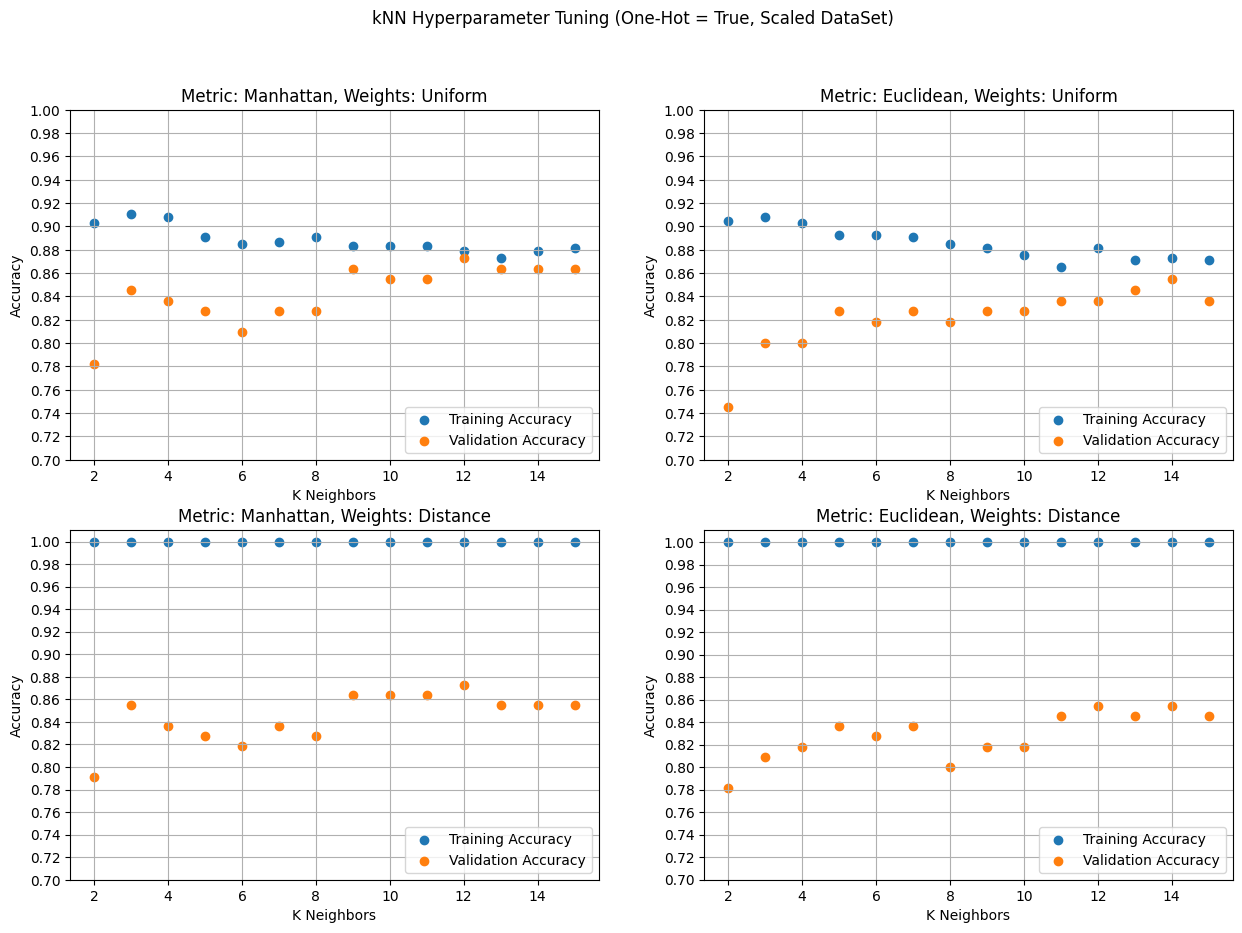

In [49]:
plt.figure(figsize = (15, 10))
plt.suptitle("kNN Hyperparameter Tuning (One-Hot = True, Scaled DataSet)")

plt.subplot(221)
plt.scatter(range(2, knn_max_neighbors + 1), knn_accu_train_all[0 : knn_max_neighbors - 1], label = "Training Accuracy")
plt.scatter(range(2, knn_max_neighbors + 1), knn_accu_valid_all[0 : knn_max_neighbors - 1], label = "Validation Accuracy")
plt.legend(loc = 4)
plt.yticks(np.arange(0.7, 1, 0.02))
plt.grid()
plt.xlabel("K Neighbors")
plt.ylabel("Accuracy")
plt.title("Metric: Manhattan, Weights: Uniform")

plt.subplot(222)
plt.scatter(range(2, knn_max_neighbors + 1), knn_accu_train_all[knn_max_neighbors - 1 : (knn_max_neighbors - 1) * 2], label = "Training Accuracy")
plt.scatter(range(2, knn_max_neighbors + 1), knn_accu_valid_all[knn_max_neighbors - 1 : (knn_max_neighbors - 1) * 2], label = "Validation Accuracy")
plt.legend(loc = 4)
plt.yticks(np.arange(0.7, 1, 0.02))
plt.grid()
plt.xlabel("K Neighbors")
plt.ylabel("Accuracy")
plt.title("Metric: Euclidean, Weights: Uniform")

plt.subplot(223)
plt.scatter(range(2, knn_max_neighbors + 1), knn_accu_train_all[(knn_max_neighbors - 1) * 2 : (knn_max_neighbors - 1) * 3], label = "Training Accuracy")
plt.scatter(range(2, knn_max_neighbors + 1), knn_accu_valid_all[(knn_max_neighbors - 1) * 2 : (knn_max_neighbors - 1) * 3], label = "Validation Accuracy")
plt.legend(loc = 4)
plt.yticks(np.arange(0.7, 1, 0.02))
plt.grid()
plt.xlabel("K Neighbors")
plt.ylabel("Accuracy")
plt.title("Metric: Manhattan, Weights: Distance")

plt.subplot(224)
plt.scatter(range(2, knn_max_neighbors + 1), knn_accu_train_all[(knn_max_neighbors - 1) * 3 : (knn_max_neighbors - 1) * 4], label = "Training Accuracy")
plt.scatter(range(2, knn_max_neighbors + 1), knn_accu_valid_all[(knn_max_neighbors - 1) * 3 : (knn_max_neighbors - 1) * 4], label = "Validation Accuracy")
plt.legend(loc = 4)
plt.yticks(np.arange(0.7, 1, 0.02))
plt.grid()
plt.xlabel("K Neighbors")
plt.ylabel("Accuracy")
plt.title("Metric: Euclidean, Weights: Distance")

plt.show()

We have reached the best Validation Accuracy of 87,273 % with both sets of hyperparameters:
* `Metric = Manhattan`
* `N_Neighbors = 12`
* `Weights = Uniform, Distance`

`Weights` both "Uniform" and "Distance" yield the same best Validation Accuracy. We can now move on and train our final kNN Model with those chosen hyperparameters:

### kNN Final Model

In [50]:
xtrain_knn_final = pd.concat([xtrain_knn, xvalid_knn], axis = 0)
knn_final = KNeighborsClassifier(**knn_params_best).fit(xtrain_knn_final, ytrain_final)
knn_final_accu_test = mtr.accuracy_score(ytest, knn_final.predict(xtest_knn))
print(f"We trained final kNN Model with Testing Accuracy = {knn_final_accu_test:.5f}")

We trained final kNN Model with Testing Accuracy = 0.87387


Our final kNN Model has reached Testing Accuracy of 87,4 %, which is above requested Testing Accuracy of **80 %**, so we can consider this model successful.

Let's take a look at ROC Curve and AUC Score of this final model:

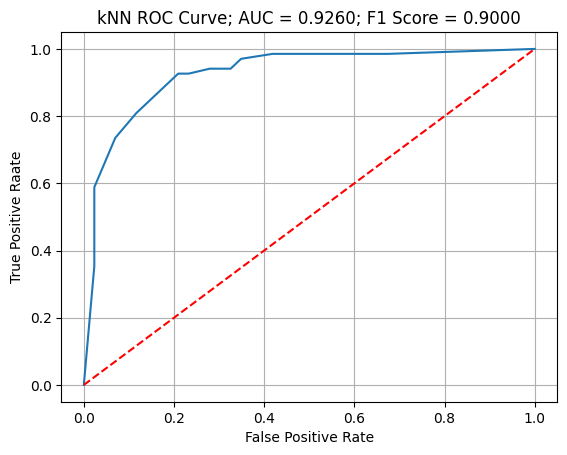

In [51]:
fpr_knn, tpr_knn, thresholds_knn = mtr.roc_curve(ytest, knn_final.predict_proba(xtest_knn)[:, 1])
AUC_knn = mtr.auc(fpr_knn, tpr_knn)
f1_knn_final = mtr.f1_score(ytest, knn_final.predict(xtest_knn))

plt.plot(fpr_knn, tpr_knn)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Raate")
plt.title(f"kNN ROC Curve; AUC = {AUC_knn:.4f}; F1 Score = {f1_knn_final:.4f}")
plt.grid()

### AdaBoos Model with Decision Tree Weak Estimators
Now we are gonna train AdaBoos prediction model. We are gonna use Decision Trees as weak estimators and since we have already trained Decision Tree Classifier Model, we will use the same data preprocessing procedure we have used with Decision Tree. We will use One-Hot encoding, as we have reached better results with it, as expected regarding Decision Tree models. We will not normalise the data, it's not important with DTs.

In [52]:
# Load dataset, drop "ID" column, split DataSet into Feature matrix and Target Variable vector
data_raw = pd.read_csv("data.csv")
data = data_raw.drop("ID", axis = 1)
ydata = data["HeartDisease"]
xdata = data.drop("HeartDisease", axis = 1)

# Train-Valid-Test split - ratios 70/15/15
xtrain, xrest, ytrain, yrest = train_test_split(xdata, ydata, test_size = 0.3, random_state = rd_seed)
xvalid, xtest, yvalid, ytest = train_test_split(xrest, yrest, test_size = 0.5, random_state = rd_seed)

# Encode "Sex" feature using category codes (binary-valued feature)
sex_cat = pd.api.types.CategoricalDtype(categories = xtrain.Sex.dropna().unique(), ordered = False)
for each in [xtrain, xvalid, xtest]:
    each["Sex"] = each["Sex"].astype(sex_cat).cat.codes
    
# Encode "Exercise Angina" feature using category codes (binary-valued feature)
exer_ang_cat = pd.api.types.CategoricalDtype(categories = xtrain["ExerciseAngina"].dropna().unique(), ordered = False)
for each in [xtrain, xvalid, xtest]:
    each["ExerciseAngina"] = each["ExerciseAngina"].astype(exer_ang_cat).cat.codes

In [53]:
xtrain_adab, xvalid_adab, xtest_adab = process_category_features(xtrain, xvalid, xtest, one_hot = True)

In [54]:
from sklearn.ensemble import AdaBoostClassifier

In [55]:
max_tree_depth = 10
adab_parameter_grid = {"max_depth" : range(1, max_tree_depth + 1),
                      "estimators" : np.arange(5, 101, 5),
                      "criterion" : ["entropy", "gini"]}
adab_params = ParameterGrid(adab_parameter_grid)
adab_accu_train_all = []
adab_accu_valid_all = []

for each in adab_params:
    n_estim = each.pop("estimators")
    adab = AdaBoostClassifier(estimator = DecisionTreeClassifier(**each, random_state = rd_seed), n_estimators = n_estim, random_state = rd_seed).fit(xtrain_adab, ytrain)
    adab_accu_train_this = mtr.accuracy_score(ytrain, adab.predict(xtrain_adab))
    adab_accu_valid_this = mtr.accuracy_score(yvalid, adab.predict(xvalid_adab))
    adab_accu_train_all.append(adab_accu_train_this)
    adab_accu_valid_all.append(adab_accu_valid_this)
    print(f"AdaBoost Decsion Tree Classifier parameters: n_estimators = {n_estim}, {each} \t Training Accuracy = {adab_accu_train_this:.5f} \t Validation Accuracy = {adab_accu_valid_this:.5f}")

AdaBoost Decsion Tree Classifier parameters: n_estimators = 5, {'criterion': 'entropy', 'max_depth': 1} 	 Training Accuracy = 0.84600 	 Validation Accuracy = 0.80000
AdaBoost Decsion Tree Classifier parameters: n_estimators = 5, {'criterion': 'entropy', 'max_depth': 2} 	 Training Accuracy = 0.87524 	 Validation Accuracy = 0.79091
AdaBoost Decsion Tree Classifier parameters: n_estimators = 5, {'criterion': 'entropy', 'max_depth': 3} 	 Training Accuracy = 0.88694 	 Validation Accuracy = 0.85455
AdaBoost Decsion Tree Classifier parameters: n_estimators = 5, {'criterion': 'entropy', 'max_depth': 4} 	 Training Accuracy = 0.94152 	 Validation Accuracy = 0.84545
AdaBoost Decsion Tree Classifier parameters: n_estimators = 5, {'criterion': 'entropy', 'max_depth': 5} 	 Training Accuracy = 0.97466 	 Validation Accuracy = 0.80909
AdaBoost Decsion Tree Classifier parameters: n_estimators = 5, {'criterion': 'entropy', 'max_depth': 6} 	 Training Accuracy = 0.99805 	 Validation Accuracy = 0.81818
AdaB

In [56]:
adab_best_index = np.argmax(adab_accu_valid_all)
adab_accu_best = adab_accu_valid_all[adab_best_index]
adab_params_best = adab_params[adab_best_index]

print(f"We found the best AdaBoost Decsion Tree Classifier Model with parameters {adab_params_best} and Validation Accuracy = {adab_accu_best:.5f}")

We found the best AdaBoost Decsion Tree Classifier Model with parameters {'max_depth': 6, 'estimators': np.int64(25), 'criterion': 'entropy'} and Validation Accuracy = 0.89091


We have too large Parameter Grid for meaningful visualisation, so let's just train the final AdaBoost Model with those tuned hyperparameters now:

### AdaBoost Final Model

In [57]:
n_estim = adab_params_best.pop("estimators")

In [58]:
xtrain_adab_final = pd.concat([xtrain_adab, xvalid_adab], axis = 0)

In [59]:
adab_final = AdaBoostClassifier(estimator = DecisionTreeClassifier(**adab_params_best, random_state = rd_seed), n_estimators = n_estim, random_state = rd_seed).fit(xtrain_adab_final, ytrain_final)
adab_accu_test = mtr.accuracy_score(ytest, adab_final.predict(xtest_adab))
print(f"We trained the final AdaBoost Decision Tree Classifier Model with Testing Accuracy = {adab_accu_test:.5f}")

We trained the final AdaBoost Decision Tree Classifier Model with Testing Accuracy = 0.82883


Our AdaBoost Model has reached prediction accuracy of 82,88 % which is > **80 %** requested. It is however exactly the same Testing Accuracy we have reached with our simple Decision Tree Model, which is a little bit disapointing, since we expeceted AdaBoost to reach higher accuracy.

Finally we can visualise the ROC Curve and compute AUC score.

Text(0.5, 1.0, 'AdaBoost ROC Curve, AUC = 0.9220; F1 Score = 0.8613')

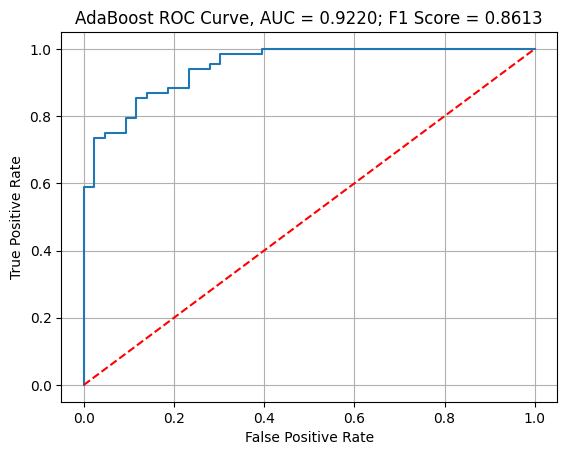

In [60]:
fpr_adab, tpr_adab, thresholds_adab = mtr.roc_curve(ytest, adab_final.predict_proba(xtest_adab)[:, 1])
auc_adab = mtr.auc(fpr_adab, tpr_adab)
f1_adab_final = mtr.f1_score(ytest, adab_final.predict(xtest_adab))

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()
plt.title(f"AdaBoost ROC Curve, AUC = {auc_adab:.4f}; F1 Score = {f1_adab_final:.4f}")

### Logistic Regression

Last model we will train is Logistic Regression Model. Since the sklearn implementation uses L2 regularisation defaultly, we will need to normalise the data. We will do the data preprocessing in the same way as with training the kNN Model - use One-Hot encoding, use Min-Max scaler on `Age` feature and Standard scaler on other non-One-Hot encoded fetures.

In [61]:
# Load dataset, drop "ID" column, split DataSet into Feature matrix and Target Variable vector
data_raw = pd.read_csv("data.csv")
data = data_raw.drop("ID", axis = 1)
ydata = data["HeartDisease"]
xdata = data.drop("HeartDisease", axis = 1)

# Train-Valid-Test split - ratios 70/15/15
xtrain, xrest, ytrain, yrest = train_test_split(xdata, ydata, test_size = 0.3, random_state = rd_seed)
xvalid, xtest, yvalid, ytest = train_test_split(xrest, yrest, test_size = 0.5, random_state = rd_seed)

# Encode "Sex" feature using category codes (binary-valued feature)
sex_cat = pd.api.types.CategoricalDtype(categories = xtrain.Sex.dropna().unique(), ordered = False)
for each in [xtrain, xvalid, xtest]:
    each["Sex"] = each["Sex"].astype(sex_cat).cat.codes
    
# Encode "Exercise Angina" feature using category codes (binary-valued feature)
exer_ang_cat = pd.api.types.CategoricalDtype(categories = xtrain["ExerciseAngina"].dropna().unique(), ordered = False)
for each in [xtrain, xvalid, xtest]:
    each["ExerciseAngina"] = each["ExerciseAngina"].astype(exer_ang_cat).cat.codes

In [62]:
xtrain_lr, xvalid_lr, xtest_lr = process_category_features(xtrain, xvalid, xtest, one_hot = True)

`Age` feature - Min-Max Scaler

In [63]:
age_scaler = MinMaxScaler().fit(xtrain_lr[["Age"]])
for each in [xtrain_lr, xvalid_lr, xtest_lr]:
    each["Age"] = age_scaler.transform(each[["Age"]])

`RestingBP` feature - Standard Scaler

In [64]:
bp_scaler = StandardScaler().fit(xtrain_lr[["RestingBP"]])
for each in [xtrain_lr, xvalid_lr, xtest_lr]:
    each["RestingBP"] = bp_scaler.transform(each[["RestingBP"]])

`Cholesterol` feature - Replace 0s as `NaN`, Standard Scaler, replace `NaN` as 0s again

In [65]:
for each in [xtrain_lr, xvalid_lr, xtest_lr]:
    each["Cholesterol"] = each["Cholesterol"].replace(0, np.nan)

In [66]:
cholesterol_scaler = StandardScaler().fit(xtrain_lr[["Cholesterol"]])
for each in [xtrain_lr, xvalid_lr, xtest_lr]:
    each["Cholesterol"] = cholesterol_scaler.transform(each[["Cholesterol"]])

In [67]:
for each in [xtrain_lr, xvalid_lr, xtest_lr]:
    each["Cholesterol"] = each["Cholesterol"].fillna(0)

`MaxHR` feature - Standard Scaler

In [68]:
HR_scaler = StandardScaler().fit(xtrain_lr[["MaxHR"]])
for each in [xtrain_lr, xvalid_lr, xtest_lr]:
    each["MaxHR"] = HR_scaler.transform(each[["MaxHR"]])

`Oldpeak` feature - Standard Scaler

In [69]:
oldpeak_scaler = StandardScaler().fit(xtrain_lr[["Oldpeak"]])
for each in [xtrain_lr, xvalid_lr, xtest_lr]:
    each["Oldpeak"] = oldpeak_scaler.transform(each[["Oldpeak"]])

Since we don't have any hyperparameters of Logistic Regression to tune, we can just train our final model right away. We will use default solver 'lbfgs' and default L2 regularisation of the model. We can merge training and validation datasets and then measure the Accuracy on Testing DatSet.

In [70]:
xtrain_lr_final = pd.concat([xtrain_lr, xvalid_lr], axis = 0)

In [71]:
from sklearn.linear_model import LogisticRegression
LogR = LogisticRegression().fit(xtrain_lr_final, ytrain_final)

LogR_accu_test = mtr.accuracy_score(ytest, LogR.predict(xtest_lr))
print(f"Logistic Regrssion Model Testing Accuracy = {LogR_accu_test:.5f}")

Logistic Regrssion Model Testing Accuracy = 0.87387


Our final Logistic Regression Model has reached Testing Accuracy of 87,39 %, which is again > **80 %** requested, so we can consider this model successful as well. Let's take a look at ROC Curve and AUC score:

Text(0.5, 1.0, 'Logistic Regression ROC Curve; AUC = 0.9176; F1 Score = 0.8986')

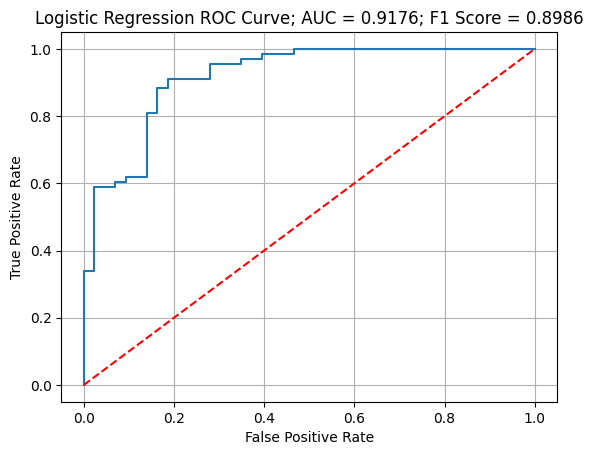

In [72]:
fpr_lr, tpr_lr, thresholds_lr = mtr.roc_curve(ytest, LogR.predict_proba(xtest_lr)[:, 1])
AUC_lr = mtr.auc(fpr_lr, tpr_lr)
f1_lr = mtr.f1_score(ytest, LogR.predict(xtest_lr))

plt.plot(fpr_lr, tpr_lr)
plt.plot([0,1], [0,1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()
plt.title(f"Logistic Regression ROC Curve; AUC = {AUC_lr:.4f}; F1 Score = {f1_lr:.4f}")

## Conclusion

We have trained 5 different prediction models with their respective metrics in the following list:
* Decision Tree:
    * Testing Accuracy = 82,9 %
    * ROC Curve AUC = 0.9036
    * F1 Score = 0.8652
* Random Forest
    * Testing Accuracy = 86,5 %
    * ROC Curve AUC = 0.9477
    * F1 Score = 0.8936
* kNN
    * Testing Accuracy = 87,4 %
    * ROC Curve AUC = 0.926
    * F1 Score = 0.9
* AdaBoost (DT Weak Estimators)
    * Testing Accuracy = 82,9 %
    * ROC Curve AUC = 0.922
    * F1 Score = 0.8613
* Logistic Regression:
    * Testing Accuracy = 87,4 %
    * ROC Curve AUC = 0.9176
    * F1 Score = 0.8986

All of those models have reached Testing Accuracy over the requested value **80 %**, so we can consider all of them successful, with kNN and Logistic Regression Models being the most accurate among all of them.